In [6]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import math
import json
import random
import multiprocessing as mp
import scipy
from collections import defaultdict
from scipy.io import loadmat
from scipy.signal import resample, butter, filtfilt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from tqdm import tqdm
import wandb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  

In [7]:
wandb.login()

True

In [12]:
# generate_plots.py
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import math
import json
import random
import multiprocessing as mp
from collections import defaultdict
from scipy.io import loadmat
from scipy.signal import resample, butter, filtfilt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from tqdm import tqdm
import wandb
import matplotlib.pyplot as plt

# Configuration (same as training)
SEED = 42
BATCH_SIZE = 48
D_MODEL = 192
N_HEADS = 6
NUM_LAYERS = 3
DROPOUT = 0.3
PATCH_LEN = 32
DATA_DIR = "processed_user"
TOKEN_DIM = PATCH_LEN * 4
WINDOW_SAMPLES = 256
NUM_WORKERS = 4
NUM_CLASSES = 171

# ============================================================
# MODEL DEFINITIONS
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EEGTokenTransformer(nn.Module):
    def __init__(self, token_dim=16, num_tokens=8, d_model=192, n_heads=6,
                 num_layers=3, num_classes=171, dropout=0.3):
        super().__init__()
        self.token_embed = nn.Linear(token_dim, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.channel_weights = nn.Parameter(torch.ones(token_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.attn_pool = nn.Linear(d_model, 1)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
    def forward(self, x):
        x = x * self.channel_weights
        x = self.token_embed(x)
        x = self.pos_encoding(x)
        x = self.encoder(x)
        weights = torch.softmax(self.attn_pool(x), dim=1)
        x = torch.sum(weights * x, dim=1)
        x = self.norm(x)
        x = F.normalize(x, dim=1)
        logits = self.classifier(x)
        return logits, x

class ArcFaceLoss(nn.Module):
    def __init__(self, embedding_dim, num_classes, s=30.0, m=0.25):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
    def forward(self, embeddings, labels):
        labels = labels.to(embeddings.device)
        embeddings = F.normalize(embeddings, dim=1)
        weights = F.normalize(self.weight, dim=1)
        cosine = F.linear(embeddings, weights)
        theta = torch.acos(torch.clamp(cosine, -1 + 1e-7, 1 - 1e-7))
        target_cos = torch.cos(theta + self.m)
        one_hot = F.one_hot(labels, num_classes=cosine.size(1)).float()
        logits = cosine * (1 - one_hot) + target_cos * one_hot
        logits *= self.s
        return F.cross_entropy(logits, labels)

def get_warmup_cosine_scheduler(optimizer, warmup_epochs, max_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs) / float(max(1, max_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def compute_strict_crr(all_preds, all_labels, threshold=0.6):
    subject_correct = defaultdict(list)
    for pred, true in zip(all_preds, all_labels):
        subject_correct[true].append(1 if pred == true else 0)
    correct = sum(1 for lst in subject_correct.values() if np.mean(lst) >= threshold)
    return correct / len(subject_correct) if subject_correct else 0

def build_templates(embeddings, labels):
    templates = {}
    for label in np.unique(labels):
        mask = labels == label
        if mask.sum() >= 1:
            templates[label] = embeddings[mask].mean(axis=0)
            templates[label] /= (np.linalg.norm(templates[label]) + 1e-8)
    return templates

def compute_eer_from_scores(genuine, impostor):
    thresholds = np.linspace(-1, 1, 500)
    best_eer, best_thresh = 1.0, 0.0
    for t in thresholds:
        far = np.mean(impostor >= t)
        frr = np.mean(genuine < t)
        eer = (far + frr) / 2
        if eer < best_eer:
            best_eer, best_thresh = eer, t
    return best_eer, best_thresh

def compute_eer_proper(model, train_loader, val_loader, device):
    """Compute EER using templates from TRAINING set, test on VALIDATION set"""
    model.eval()
    
    # Extract training embeddings for templates
    train_embs, train_lbls = [], []
    with torch.no_grad():
        for X, y in train_loader:
            X = X.to(device)
            _, emb = model(X)
            train_embs.append(emb.cpu().numpy())
            train_lbls.append(y.cpu().numpy())
    train_embs = np.concatenate(train_embs)
    train_lbls = np.concatenate(train_lbls)
    train_embs /= (np.linalg.norm(train_embs, axis=1, keepdims=True) + 1e-8)
    
    # Extract validation embeddings
    val_embs, val_lbls = [], []
    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            _, emb = model(X)
            val_embs.append(emb.cpu().numpy())
            val_lbls.append(y.cpu().numpy())
    val_embs = np.concatenate(val_embs)
    val_lbls = np.concatenate(val_lbls)
    val_embs /= (np.linalg.norm(val_embs, axis=1, keepdims=True) + 1e-8)
    
    # Build templates from TRAINING set
    templates = build_templates(train_embs, train_lbls)
    if len(templates) == 0:
        return None
    
    # Compute similarity on VALIDATION set
    template_matrix = np.stack(list(templates.values()))
    sim_matrix = cosine_similarity(val_embs, template_matrix)
    
    subj_to_idx = {s: i for i, s in enumerate(templates.keys())}
    genuine, impostor = [], []
    for i, label in enumerate(val_lbls):
        if label in subj_to_idx:
            true_idx = subj_to_idx[label]
            genuine.append(sim_matrix[i, true_idx])
            for j in range(len(templates)):
                if j != true_idx:
                    impostor.append(sim_matrix[i, j])
    
    if len(genuine) == 0 or len(impostor) == 0:
        return None
    
    eer, _ = compute_eer_from_scores(np.array(genuine), np.array(impostor))
    return eer

# ============================================================
# DATASET CLASS
# ============================================================
class EEGTokenDataset(Dataset):
    def __init__(self, data_dir):
        self.X = np.load(os.path.join(data_dir, "X_tokens.npy"))
        y_raw = np.load(os.path.join(data_dir, "y_labels.npy"))
        unique_users = np.unique(y_raw)
        self.user_to_class = {u: i for i, u in enumerate(unique_users)}
        self.y = np.array([self.user_to_class[u] for u in y_raw], dtype=np.int64)
        print(f"Loaded {len(self.X)} samples, {len(unique_users)} classes")
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)

def load_best_fold():
    """Find the best fold from kfold_aggregated_results.json"""
    with open("kfold_aggregated_results.json", "r") as f:
        results = json.load(f)
    best_fold_id = results['best_fold']
    best_eer = results['folds'][best_fold_id-1]['best_eer']
    print(f"Best fold: {best_fold_id} with EER = {best_eer*100:.2f}%")
    return best_fold_id, best_eer

def extract_embeddings(model, loader, device):
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            _, emb = model(X)
            embeddings.append(emb.cpu().numpy())
            labels.append(y.numpy())
    embeddings = np.concatenate(embeddings)
    labels = np.concatenate(labels)
    embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    return embeddings, labels

def build_templates(embeddings, labels):
    templates = {}
    for label in np.unique(labels):
        mask = labels == label
        if mask.sum() >= 1:
            templates[label] = embeddings[mask].mean(axis=0)
            templates[label] /= (np.linalg.norm(templates[label]) + 1e-8)
    return templates

In [13]:
# ============================================================
# SETUP
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

dataset = EEGTokenDataset(DATA_DIR)
labels = dataset.y

print(f"Dataset size: {len(dataset)}")
print(f"Number of classes: {len(np.unique(labels))}")
print(f"Device: {device}")

Loaded 353015 samples, 171 classes
Dataset size: 353015
Number of classes: 171
Device: cuda



FOLD-WISE EVALUATION

Evaluating Fold 1...
Fold 1: EER=2.1013% | ACC=85.97% | CRR=95.32%

Evaluating Fold 2...
Fold 2: EER=2.1370% | ACC=85.83% | CRR=95.32%

Evaluating Fold 3...
Fold 3: EER=2.1158% | ACC=85.78% | CRR=94.15%

Evaluating Fold 4...
Fold 4: EER=2.0641% | ACC=85.86% | CRR=95.32%

Evaluating Fold 5...
Fold 5: EER=2.1422% | ACC=85.75% | CRR=93.57%


Fold    EER (%)        Accuracy (%)      CRR@60 (%)     
1       2.1013         85.97             95.32          
2       2.1370         85.83             95.32          
3       2.1158         85.78             94.15          
4       2.0641         85.86             95.32          
5       2.1422         85.75             93.57          
Mean    2.1121         85.84             94.74          
Std     0.0282         0.07              0.74           

Best Fold = 4 (EER = 2.0641%)

Saved metrics to checkpoint_reproducibility_results.json
Loaded model from kfold_fold_4_best_eer.pt
Fold 4 Proper EER = 2.0641%


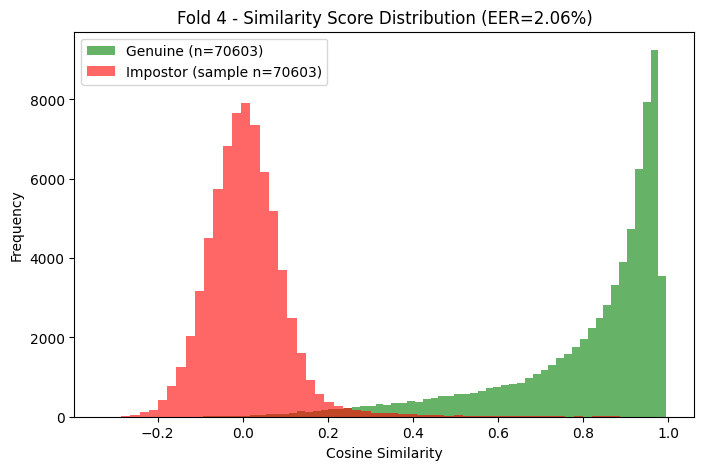

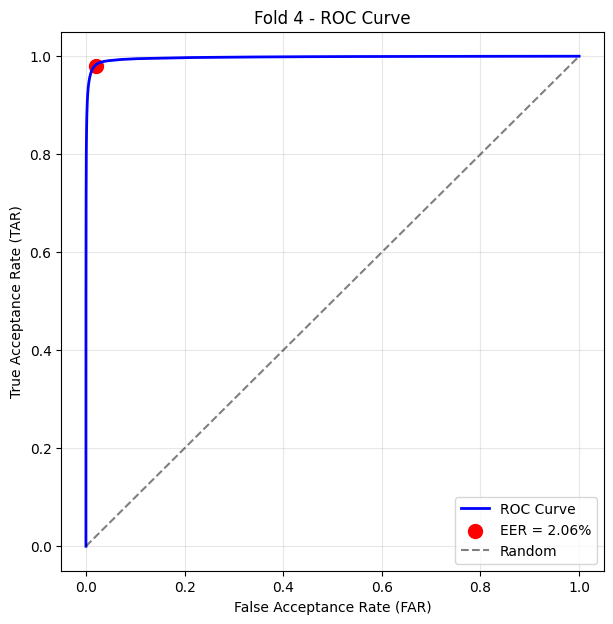

Running t-SNE...


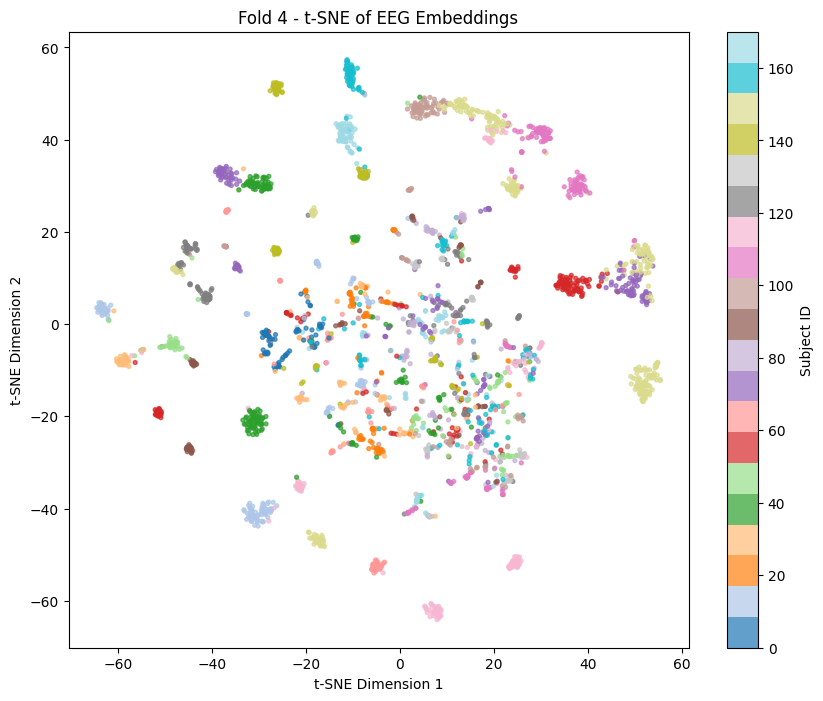

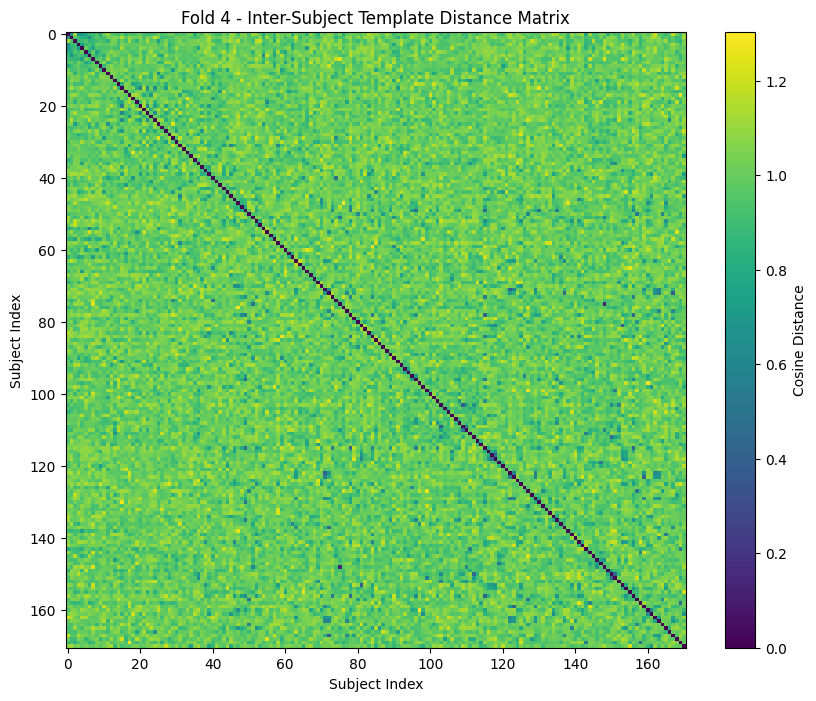


Graphs saved for Fold 4:
  - kfold_best_fold_4_similarity.png
  - kfold_best_fold_4_roc.png
  - kfold_best_fold_4_tsne.png
  - kfold_best_fold_4_heatmap.png


In [15]:
# ============================================================
# EVALUATE ALL FOLDS
# ============================================================

print("\n" + "="*70)
print("FOLD-WISE EVALUATION")
print("="*70)

results = []

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

folds = list(skf.split(dataset.X, labels))

for fold_id in range(1, 6):

    print(f"\nEvaluating Fold {fold_id}...")

    train_idx, val_idx = folds[fold_id - 1]

    train_set = Subset(dataset, train_idx)
    val_set = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # ========================================================
    # EER CHECKPOINT
    # ========================================================

    eer_model = EEGTokenTransformer(
        token_dim=TOKEN_DIM,
        num_tokens=8,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    ).to(device)

    eer_model.load_state_dict(
        torch.load(
            f"kfold_fold_{fold_id}_best_eer.pt",
            map_location=device
        )
    )

    eer_model.eval()

    eer = compute_eer_proper(
        eer_model,
        train_loader,
        val_loader,
        device
    )

    # ========================================================
    # ACCURACY CHECKPOINT
    # ========================================================

    acc_model = EEGTokenTransformer(
        token_dim=TOKEN_DIM,
        num_tokens=8,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    ).to(device)

    acc_model.load_state_dict(
        torch.load(
            f"kfold_fold_{fold_id}_best_acc.pt",
            map_location=device
        )
    )

    acc_model.eval()

    preds = []
    labels_true = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device)

            logits, _ = acc_model(X)

            preds.extend(
                logits.argmax(dim=1).cpu().numpy()
            )

            labels_true.extend(
                y.numpy()
            )

    acc = accuracy_score(
        labels_true,
        preds
    )

    # ========================================================
    # CRR CHECKPOINT
    # ========================================================

    crr_model = EEGTokenTransformer(
        token_dim=TOKEN_DIM,
        num_tokens=8,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT
    ).to(device)

    crr_model.load_state_dict(
        torch.load(
            f"kfold_fold_{fold_id}_best_crr.pt",
            map_location=device
        )
    )

    crr_model.eval()

    preds = []
    labels_true = []

    with torch.no_grad():

        for X, y in val_loader:

            X = X.to(device)

            logits, _ = crr_model(X)

            preds.extend(
                logits.argmax(dim=1).cpu().numpy()
            )

            labels_true.extend(
                y.numpy()
            )

    crr = compute_strict_crr(
        preds,
        labels_true,
        threshold=0.6
    )

    results.append({
        "fold": fold_id,
        "eer": eer,
        "acc": acc,
        "crr": crr
    })

    print(
        f"Fold {fold_id}: "
        f"EER={eer*100:.4f}% | "
        f"ACC={acc*100:.2f}% | "
        f"CRR={crr*100:.2f}%"
    )

# ============================================================
# PRINT SUMMARY
# ============================================================

print("\n")
print("="*70)
print(f"{'Fold':<8}{'EER (%)':<15}{'Accuracy (%)':<18}{'CRR@60 (%)':<15}")
print("="*70)

for r in results:

    print(
        f"{r['fold']:<8}"
        f"{r['eer']*100:<15.4f}"
        f"{r['acc']*100:<18.2f}"
        f"{r['crr']*100:<15.2f}"
    )

print("="*70)

print(
    f"{'Mean':<8}"
    f"{np.mean([r['eer'] for r in results])*100:<15.4f}"
    f"{np.mean([r['acc'] for r in results])*100:<18.2f}"
    f"{np.mean([r['crr'] for r in results])*100:<15.2f}"
)

print(
    f"{'Std':<8}"
    f"{np.std([r['eer'] for r in results])*100:<15.4f}"
    f"{np.std([r['acc'] for r in results])*100:<18.2f}"
    f"{np.std([r['crr'] for r in results])*100:<15.2f}"
)

print("="*70)

best_result = min(
    results,
    key=lambda x: x["eer"]
)

best_fold_id = best_result["fold"]
best_eer = best_result["eer"]

print(
    f"\nBest Fold = {best_fold_id} "
    f"(EER = {best_eer*100:.4f}%)"
)

summary_results = {
    "folds": results,
    "mean_eer": float(np.mean([r["eer"] for r in results])),
    "std_eer": float(np.std([r["eer"] for r in results])),
    "mean_acc": float(np.mean([r["acc"] for r in results])),
    "std_acc": float(np.std([r["acc"] for r in results])),
    "mean_crr": float(np.mean([r["crr"] for r in results])),
    "std_crr": float(np.std([r["crr"] for r in results])),
    "best_fold": best_fold_id
}

with open("checkpoint_reproducibility_results.json", "w") as f:
    json.dump(summary_results, f, indent=2)

print(
    "\nSaved metrics to "
    "checkpoint_reproducibility_results.json"
)

fold_idx = best_fold_id - 1
train_idx, val_idx = folds[fold_idx]

train_set = Subset(dataset, train_idx)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Create validation loader
val_set = Subset(dataset, val_idx)
val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Load model
model = EEGTokenTransformer(
    token_dim=TOKEN_DIM,
    num_tokens=8,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

model_path = f"kfold_fold_{best_fold_id}_best_eer.pt"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(f"Loaded model from {model_path}")

eer = compute_eer_proper(
    model,
    train_loader,
    val_loader,
    device
)

print(f"Fold {best_fold_id} Proper EER = {eer*100:.4f}%")

val_embeddings, val_labels = extract_embeddings(
    model,
    val_loader,
    device
)

templates = build_templates(
    val_embeddings,
    val_labels
)

# Compute similarity matrix
template_matrix = np.stack(list(templates.values()))
sim_matrix = cosine_similarity(val_embeddings, template_matrix)

# Extract genuine and impostor scores
subj_to_idx = {s: i for i, s in enumerate(templates.keys())}

genuine, impostor = [], []

for i, label in enumerate(val_labels):
    if label in subj_to_idx:
        true_idx = subj_to_idx[label]
        genuine.append(sim_matrix[i, true_idx])

        for j in range(len(templates)):
            if j != true_idx:
                impostor.append(sim_matrix[i, j])

genuine = np.array(genuine)
impostor = np.array(impostor)

# Compute FAR/FRR for ROC
thresholds = np.linspace(-1, 1, 500)

FAR, FRR = [], []

for t in thresholds:
    FAR.append(np.mean(impostor >= t))
    FRR.append(np.mean(genuine < t))

FAR = np.array(FAR)
FRR = np.array(FRR)
TAR = 1 - FRR

# Plot similarity distribution
plt.figure(figsize=(8, 5))

impostor_sample = np.random.choice(
    impostor,
    size=min(len(genuine), len(impostor)),
    replace=False
)

plt.hist(
    genuine,
    bins=60,
    alpha=0.6,
    label=f'Genuine (n={len(genuine)})',
    color='green'
)

plt.hist(
    impostor_sample,
    bins=60,
    alpha=0.6,
    label=f'Impostor (sample n={len(impostor_sample)})',
    color='red'
)

plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title(
    f'Fold {best_fold_id} - Similarity Score Distribution '
    f'(EER={eer*100:.2f}%)'
)
plt.legend()
plt.savefig(
    f'kfold_best_fold_{best_fold_id}_similarity.png',
    dpi=150
)
plt.show()

# Plot ROC curve
plt.figure(figsize=(7, 7))

plt.plot(
    FAR,
    TAR,
    'b-',
    linewidth=2,
    label='ROC Curve'
)

plt.scatter(
    eer,
    1 - eer,
    color='red',
    s=100,
    label=f'EER = {eer*100:.2f}%'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.5,
    label='Random'
)

plt.xlabel('False Acceptance Rate (FAR)')
plt.ylabel('True Acceptance Rate (TAR)')
plt.title(f'Fold {best_fold_id} - ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    f'kfold_best_fold_{best_fold_id}_roc.png',
    dpi=150
)

plt.show()

# t-SNE
print("Running t-SNE...")

max_points = min(3000, len(val_embeddings))

indices = np.random.choice(
    len(val_embeddings),
    max_points,
    replace=False
)

tsne_data = val_embeddings[indices]
tsne_labels = val_labels[indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca'
)

tsne_2d = tsne.fit_transform(tsne_data)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    tsne_2d[:, 0],
    tsne_2d[:, 1],
    c=tsne_labels,
    s=8,
    cmap='tab20',
    alpha=0.7
)

plt.colorbar(scatter, label='Subject ID')

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.title(
    f'Fold {best_fold_id} - t-SNE of EEG Embeddings'
)

plt.savefig(
    f'kfold_best_fold_{best_fold_id}_tsne.png',
    dpi=150
)

plt.show()

# Distance heatmap
template_vectors = np.stack(list(templates.values()))

dist_matrix = cdist(
    template_vectors,
    template_vectors,
    metric='cosine'
)

plt.figure(figsize=(10, 8))

plt.imshow(
    dist_matrix,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(label='Cosine Distance')

plt.title(
    f'Fold {best_fold_id} - Inter-Subject Template Distance Matrix'
)

plt.xlabel('Subject Index')
plt.ylabel('Subject Index')

plt.savefig(
    f'kfold_best_fold_{best_fold_id}_heatmap.png',
    dpi=150
)

plt.show()

print(f"\nGraphs saved for Fold {best_fold_id}:")
print(f"  - kfold_best_fold_{best_fold_id}_similarity.png")
print(f"  - kfold_best_fold_{best_fold_id}_roc.png")
print(f"  - kfold_best_fold_{best_fold_id}_tsne.png")
print(f"  - kfold_best_fold_{best_fold_id}_heatmap.png")